# Firefly Algorithm 



The objective is to select a compact and stable set of physical QSpin OPM sensors for classifying:

- `cue_Left`
- `cue_Right`

Each physical sensor remains one selectable unit, with all available X, Y and Z channels grouped together.



## Scientific distinction

Two results are produced:

1. **Full-data consensus selection** — useful for ranking and deployment, but exploratory.
2. **Nested cross-validation** — Firefly selection runs only inside each outer training fold and provides the defensible generalisation estimate.

Report nested-CV performance as the primary result.

## 1. Install compatible packages

In [1]:
%pip install -q --upgrade "mne==1.9.0" "scikit-learn>=1.4,<1.7" joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 49.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


Restart the Kaggle session only if requested, then continue from the imports cell.

## 2. Imports and environment

In [2]:
from __future__ import annotations

import json
import re
import shutil
import sys
import warnings
import zipfile
from collections import Counter, defaultdict
from dataclasses import dataclass
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_val_score,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

print("Python:", sys.version.split()[0])
print("MNE:", mne.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

try:
    import sklearn
    print("scikit-learn:", sklearn.__version__)
except Exception:
    pass

try:
    import psutil
    memory = psutil.virtual_memory()
    print(
        f"Available RAM: {memory.available / 1024**3:.2f} GiB / "
        f"{memory.total / 1024**3:.2f} GiB"
    )
except Exception:
    print("psutil unavailable; RAM report skipped.")

Python: 3.12.13
MNE: 1.9.0
NumPy: 2.4.6
Pandas: 2.3.3
scikit-learn: 1.6.1
Available RAM: 30.25 GiB / 31.35 GiB


## 3. Configuration

In [3]:
INPUT_ROOT = Path("/kaggle/input")
WORK_ROOT = Path("/kaggle/working/flux_firefly")
EXTRACT_ROOT = WORK_ROOT / "extracted_epochs"
FIGURE_ROOT = WORK_ROOT / "figures"
REPORT_ROOT = WORK_ROOT / "reports"
MODEL_ROOT = WORK_ROOT / "models"

for directory in (
    WORK_ROOT,
    EXTRACT_ROOT,
    FIGURE_ROOT,
    REPORT_ROOT,
    MODEL_ROOT,
):
    directory.mkdir(parents=True, exist_ok=True)

SUBJECT = "01"
SESSION = "01"
TASK = "SpAtt"
RUN = "01"

EPOCHS_FILE_OVERRIDE = None

# First validation run.
QUICK_MODE = True
QUICK_TRIALS_PER_CONDITION = 40

FILTER_L_FREQ_HZ = 1.0
FILTER_H_FREQ_HZ = 30.0
FILTER_ORDER = 4
RESAMPLE_HZ = 100.0

FEATURE_TMIN_S = 0.00
FEATURE_TMAX_S = 0.80
N_TIME_WINDOWS = 8
FEATURE_STATS = ("mean", "std", "rms")

REQUIRE_COMPLETE_XYZ = False

# Arnab Sir's top-10 experiment.
# Change to 30 or 35 for the reduced-headset analysis.
TARGET_SENSOR_COUNT = 10

# Firefly hyperparameters.
FIREFLY_BETA0 = 1.0
FIREFLY_GAMMA = 1.0
FIREFLY_ALPHA_INITIAL = 0.25
FIREFLY_ALPHA_DECAY = 0.96
FIREFLY_ALPHA_MIN = 0.02

# Fraction of the initial position influenced by the univariate heuristic.
HEURISTIC_INITIALISATION_STRENGTH = 0.60

QUICK_FIREFLIES = 8
QUICK_ITERATIONS = 8
QUICK_RUNS = 2

FINAL_FIREFLIES = 25
FINAL_ITERATIONS = 40
FINAL_RUNS = 10

REDUNDANCY_WEIGHT = 0.02

SVM_C = 1.0
SVM_CLASS_WEIGHT = None

RANDOM_STATE = 42

QUICK_INNER_SPLITS = 3
FINAL_INNER_SPLITS = 5

RUN_NESTED_CV = True
QUICK_OUTER_SPLITS = 3
FINAL_OUTER_SPLITS = 5

INNER_N_JOBS = 1
OUTER_N_JOBS = 1

CONSENSUS_CV_SPLITS = 5
CONSENSUS_CV_REPEATS = 5

RANDOM_BASELINE_REPEATS = 30

RUN_SENSOR_COUNT_CURVE = False
SENSOR_COUNTS_TO_TEST = [5, 10, 15, 20, 25, 30, 35]
COUNT_CURVE_FIREFLIES = 10
COUNT_CURVE_ITERATIONS = 10

RUN_TIME_RESOLVED_DECODING = True
TIME_DECODING_TMIN_S = -0.10
TIME_DECODING_TMAX_S = 1.00
TIME_DECODING_CV_SPLITS = 5

TOP_SENSORS_FOR_ENERGY_PLOTS = 5

N_FIREFLIES = (
    QUICK_FIREFLIES
    if QUICK_MODE
    else FINAL_FIREFLIES
)
FIREFLY_ITERATIONS = (
    QUICK_ITERATIONS
    if QUICK_MODE
    else FINAL_ITERATIONS
)
FIREFLY_RUNS = (
    QUICK_RUNS
    if QUICK_MODE
    else FINAL_RUNS
)
INNER_SPLITS = (
    QUICK_INNER_SPLITS
    if QUICK_MODE
    else FINAL_INNER_SPLITS
)
OUTER_SPLITS = (
    QUICK_OUTER_SPLITS
    if QUICK_MODE
    else FINAL_OUTER_SPLITS
)

print("Quick mode:", QUICK_MODE)
print("Target sensors:", TARGET_SENSOR_COUNT)
print(
    "Fireflies / iterations / runs:",
    N_FIREFLIES,
    FIREFLY_ITERATIONS,
    FIREFLY_RUNS,
)

Quick mode: True
Target sensors: 10
Fireflies / iterations / runs: 8 8 2


## Locating epoch file

In [4]:
def is_probable_first_split(path):
    name = path.name.casefold()

    if "split-" not in name and not re.search(r"-\d+\.fif$", name):
        return True

    return bool(
        re.search(
            r"(?:_|-)split-0*1(?:_|-)",
            name,
        )
    )


def resolve_override(value, label):
    if value is None:
        return None

    path = Path(value)

    if not path.exists():
        raise FileNotFoundError(
            f"{label} override does not exist: {path}"
        )

    return path


override = resolve_override(
    EPOCHS_FILE_OVERRIDE,
    "Epochs file",
)

if override is not None:
    epoch_candidates = [override]

else:
    epoch_candidates = [
        path
        for path in INPUT_ROOT.rglob("*.fif")
        if (
            path.name.casefold().endswith("_epo.fif")
            or "_epo-" in path.name.casefold()
        )
        and is_probable_first_split(path)
    ]

    if not epoch_candidates:
        archives = [
            path
            for path in INPUT_ROOT.rglob("*.zip")
            if (
                "epoch" in path.name.casefold()
                or "condition" in path.name.casefold()
            )
            and "figure" not in path.name.casefold()
            and "report" not in path.name.casefold()
        ]

        for index, archive_path in enumerate(archives):
            destination = (
                EXTRACT_ROOT
                / f"archive_{index:02d}_{archive_path.stem}"
            )
            destination.mkdir(
                parents=True,
                exist_ok=True,
            )

            print("Extracting:", archive_path)

            with zipfile.ZipFile(archive_path, "r") as archive:
                archive.extractall(destination)

        epoch_candidates = [
            path
            for path in EXTRACT_ROOT.rglob("*.fif")
            if (
                path.name.casefold().endswith("_epo.fif")
                or "_epo-" in path.name.casefold()
            )
            and is_probable_first_split(path)
        ]

    epoch_candidates = sorted(
        epoch_candidates,
        key=lambda path: (
            int(
                "quick" not in path.name.casefold()
                and "test" not in path.name.casefold()
            ),
            int("desc-cue" in path.name.casefold()),
            int("analysis" in str(path).casefold()),
            str(path),
        ),
        reverse=True,
    )

if not epoch_candidates:
    raise FileNotFoundError(
        "No condition-specific epoch FIF was found."
    )

print("Epoch candidates:")

for index, path in enumerate(epoch_candidates[:20]):
    print(f"  [{index}] {path}")

EPOCHS_FILE = epoch_candidates[0]

print("\nSelected:", EPOCHS_FILE)

Epoch candidates:
  [0] /kaggle/input/datasets/srijanroysr10/cercaoxf/CercaOxf/fif/Cerca_Spatt_BIDS/derivatives/analysis/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_epo.fif

Selected: /kaggle/input/datasets/srijanroysr10/cercaoxf/CercaOxf/fif/Cerca_Spatt_BIDS/derivatives/analysis/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_epo.fif


## Epoch Auditing

In [5]:
epochs = mne.read_epochs(
    EPOCHS_FILE,
    proj=False,
    preload=True,
    verbose=True,
)

print(epochs)
print("Conditions:", epochs.event_id)
print("Channels:", len(epochs.ch_names))
print("Sampling frequency:", epochs.info["sfreq"])
print("Epoch interval:", (epochs.tmin, epochs.tmax))
print("Bad channels:", epochs.info.get("bads", []))

condition_count_df = pd.DataFrame(
    [
        {
            "condition": condition,
            "epochs": len(epochs[condition]),
        }
        for condition in epochs.event_id
    ]
).sort_values("condition")

display(condition_count_df)

condition_count_df.to_csv(
    REPORT_ROOT / "input_condition_counts.csv",
    index=False,
)

Reading /kaggle/input/datasets/srijanroysr10/cercaoxf/CercaOxf/fif/Cerca_Spatt_BIDS/derivatives/analysis/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_epo.fif ...
    Read a total of 8 projection items:
        HFC: l=1 m=-1 (1 x 180) active
        HFC: l=1 m=0 (1 x 180) active
        HFC: l=1 m=1 (1 x 180) active
        HFC: l=2 m=-2 (1 x 180) active
        HFC: l=2 m=-1 (1 x 180) active
        HFC: l=2 m=0 (1 x 180) active
        HFC: l=2 m=1 (1 x 180) active
        HFC: l=2 m=2 (1 x 180) active
    Found the data of interest:
        t =    -749.33 ...    2000.00 ms
        0 CTF compensation matrices available
Not setting metadata
219 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 8)
<EpochsFIF | 219 events (all good), -0.749 – 2 s (baseline off), ~719.1 MiB, data loaded,
 'cue_Left': 113
 'cue_Right': 106>
Conditions: {'cue_Left': 5, 'cue_Right': 6}
Channels: 207
Sampling frequency: 750.0
Epoch interval: (np.float64(-0

,condition,epochs
0,cue_Left,113
1,cue_Right,106


##  cue-left / cue-right 

In [6]:
def normalise_condition_name(name):
    return "_".join(
        re.findall(
            r"[a-z0-9]+",
            str(name).casefold(),
        )
    )


def identify_condition(event_id, direction):
    matches = []

    for condition_name in event_id:
        normalised = normalise_condition_name(
            condition_name
        )
        tokens = set(normalised.split("_"))

        if (
            ("cue" in tokens or normalised.startswith("cue"))
            and direction.casefold() in tokens
        ):
            matches.append(condition_name)

    if len(matches) != 1:
        raise ValueError(
            f"Expected one cue-{direction} condition, "
            f"found {matches}. Available: {event_id}"
        )

    return matches[0]


left_condition = identify_condition(
    epochs.event_id,
    "left",
)
right_condition = identify_condition(
    epochs.event_id,
    "right",
)

print(
    "Cue-left:",
    left_condition,
    len(epochs[left_condition]),
)
print(
    "Cue-right:",
    right_condition,
    len(epochs[right_condition]),
)

Cue-left: cue_Left 113
Cue-right: cue_Right 106


## Channel Mapping

In [7]:
_AXIS_PATTERN = re.compile(
    r"(?:^|[\s_-])([XYZ])$",
    flags=re.IGNORECASE,
)


def infer_axis(channel_name):
    match = _AXIS_PATTERN.search(
        channel_name.strip()
    )

    if match:
        return match.group(1).upper()

    if (
        channel_name
        and channel_name.strip()[-1].upper()
        in {"X", "Y", "Z"}
    ):
        return channel_name.strip()[-1].upper()

    return None


def physical_sensor_name(channel_name):
    name = re.sub(
        r"(?:[\s_-]+)[XYZ]$",
        "",
        channel_name.strip(),
        flags=re.IGNORECASE,
    )

    return re.sub(
        r"\s+",
        " ",
        name,
    ).strip()


good_mag_names = [
    name
    for name, channel_type in zip(
        epochs.ch_names,
        epochs.get_channel_types(),
    )
    if channel_type == "mag"
    and name not in epochs.info.get("bads", [])
]

sensor_to_channels = defaultdict(list)

for channel_name in good_mag_names:
    axis = infer_axis(channel_name)

    if axis is not None:
        sensor_to_channels[
            physical_sensor_name(channel_name)
        ].append(channel_name)

sensor_rows = []

for sensor_name, channels in sorted(
    sensor_to_channels.items()
):
    axes = sorted(
        axis
        for axis in (
            infer_axis(channel)
            for channel in channels
        )
        if axis is not None
    )

    sensor_rows.append(
        {
            "physical_sensor": sensor_name,
            "n_channels": len(channels),
            "axes": ",".join(axes),
            "complete_xyz": (
                set(axes) == {"X", "Y", "Z"}
            ),
            "channels": "|".join(channels),
        }
    )

sensor_inventory_df = pd.DataFrame(sensor_rows)

if REQUIRE_COMPLETE_XYZ:
    retained_sensor_names = (
        sensor_inventory_df.loc[
            sensor_inventory_df["complete_xyz"],
            "physical_sensor",
        ].tolist()
    )
else:
    retained_sensor_names = (
        sensor_inventory_df[
            "physical_sensor"
        ].tolist()
    )

sensor_inventory_df[
    "retained_for_firefly"
] = sensor_inventory_df[
    "physical_sensor"
].isin(retained_sensor_names)

display(sensor_inventory_df)

sensor_inventory_df.to_csv(
    REPORT_ROOT / "physical_sensor_inventory.csv",
    index=False,
)

print("Good magnetometer channels:", len(good_mag_names))
print("Physical sensors discovered:", len(sensor_inventory_df))
print("Physical sensors retained:", len(retained_sensor_names))

if TARGET_SENSOR_COUNT > len(retained_sensor_names):
    raise ValueError(
        "TARGET_SENSOR_COUNT exceeds the available sensor count."
    )

,physical_sensor,n_channels,axes,complete_xyz,channels,retained_for_firefly
0,C1 A7,3,"X,Y,Z",True,C1 A7 Z|C1 A7 Y|C1 A7 X,True
1,C2 B5,3,"X,Y,Z",True,C2 B5 Z|C2 B5 Y|C2 B5 X,True
2,C3 C2,3,"X,Y,Z",True,C3 C2 Z|C3 C2 Y|C3 C2 X,True
3,C4 D7,3,"X,Y,Z",True,C4 D7 Z|C4 D7 Y|C4 D7 X,True
4,C5 C1,3,"X,Y,Z",True,C5 C1 Z|C5 C1 Y|C5 C1 X,True
...,...,...,...,...,...,...
57,T5 C5,1,X,False,T5 C5 X,True
58,T6 D6,3,"X,Y,Z",True,T6 D6 Z|T6 D6 Y|T6 D6 X,True
59,T7 C8,3,"X,Y,Z",True,T7 C8 Z|T7 C8 Y|T7 C8 X,True
60,T8 D2,3,"X,Y,Z",True,T8 D2 Z|T8 D2 Y|T8 D2 X,True


Good magnetometer channels: 180
Physical sensors discovered: 62
Physical sensors retained: 62


## Data Sampling

In [8]:
selected_channel_names = []

for sensor_name in retained_sensor_names:
    selected_channel_names.extend(
        sensor_to_channels[sensor_name]
    )

epochs_signal = epochs.copy().pick(
    selected_channel_names
)


def select_evenly_spaced(
    condition_epochs,
    requested_count,
):
    if requested_count >= len(condition_epochs):
        return condition_epochs

    indices = np.unique(
        np.linspace(
            0,
            len(condition_epochs) - 1,
            requested_count,
        ).round().astype(int)
    )

    return condition_epochs[indices]


if QUICK_MODE:
    left_epochs = select_evenly_spaced(
        epochs_signal[left_condition],
        QUICK_TRIALS_PER_CONDITION,
    )
    right_epochs = select_evenly_spaced(
        epochs_signal[right_condition],
        QUICK_TRIALS_PER_CONDITION,
    )
else:
    left_epochs = epochs_signal[left_condition]
    right_epochs = epochs_signal[right_condition]

epochs_signal = mne.concatenate_epochs(
    [left_epochs, right_epochs],
    add_offset=True,
    on_mismatch="raise",
    verbose=False,
)

y = np.concatenate(
    [
        np.zeros(
            len(left_epochs),
            dtype=int,
        ),
        np.ones(
            len(right_epochs),
            dtype=int,
        ),
    ]
)

iir_params = {
    "order": FILTER_ORDER,
    "ftype": "butter",
    "output": "sos",
}

epochs_signal.filter(
    l_freq=FILTER_L_FREQ_HZ,
    h_freq=FILTER_H_FREQ_HZ,
    picks="mag",
    method="iir",
    iir_params=iir_params,
    phase="zero",
    verbose=True,
)

epochs_signal.resample(
    RESAMPLE_HZ,
    npad="auto",
    verbose=True,
)

if (
    FEATURE_TMIN_S < epochs_signal.tmin
    or FEATURE_TMAX_S > epochs_signal.tmax
):
    raise ValueError(
        "The feature interval lies outside the epoch."
    )

X_signal = epochs_signal.get_data(
    copy=True
)
signal_times = epochs_signal.times.copy()
signal_channel_names = list(
    epochs_signal.ch_names
)

print("Signal matrix:", X_signal.shape)
print("Labels:", np.bincount(y, minlength=2))

Setting up band-pass filter from 1 - 30 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 1.00, 30.00 Hz: -6.02, -6.02 dB

Signal matrix: (80, 180, 275)
Labels: [40 40]


## Feature Extraction

In [9]:
window_edges = np.linspace(
    FEATURE_TMIN_S,
    FEATURE_TMAX_S,
    N_TIME_WINDOWS + 1,
)

channel_index = {
    channel_name: index
    for index, channel_name
    in enumerate(signal_channel_names)
}

feature_blocks = []
feature_names = []
sensor_feature_columns = {}
column_start = 0

for sensor_name in retained_sensor_names:
    sensor_channels = [
        channel
        for channel
        in sensor_to_channels[sensor_name]
        if channel in channel_index
    ]

    sensor_indices = [
        channel_index[channel]
        for channel in sensor_channels
    ]

    sensor_data = X_signal[
        :,
        sensor_indices,
        :,
    ]

    sensor_features = []
    sensor_feature_names = []

    for window_index in range(
        N_TIME_WINDOWS
    ):
        tmin = window_edges[
            window_index
        ]
        tmax = window_edges[
            window_index + 1
        ]

        if (
            window_index
            == N_TIME_WINDOWS - 1
        ):
            time_mask = (
                (signal_times >= tmin)
                & (signal_times <= tmax)
            )
        else:
            time_mask = (
                (signal_times >= tmin)
                & (signal_times < tmax)
            )

        if not np.any(time_mask):
            raise ValueError(
                f"No samples in {tmin}–{tmax} s."
            )

        window_data = sensor_data[
            :,
            :,
            time_mask,
        ]

        for local_index, channel_name in enumerate(
            sensor_channels
        ):
            axis = infer_axis(channel_name)
            axis_data = window_data[
                :,
                local_index,
                :,
            ]

            if "mean" in FEATURE_STATS:
                sensor_features.append(
                    np.mean(axis_data, axis=1)
                )
                sensor_feature_names.append(
                    f"{sensor_name}|{axis}|w{window_index}|mean"
                )

            if "std" in FEATURE_STATS:
                sensor_features.append(
                    np.std(axis_data, axis=1)
                )
                sensor_feature_names.append(
                    f"{sensor_name}|{axis}|w{window_index}|std"
                )

            if "rms" in FEATURE_STATS:
                sensor_features.append(
                    np.sqrt(
                        np.mean(
                            axis_data**2,
                            axis=1,
                        )
                    )
                )
                sensor_feature_names.append(
                    f"{sensor_name}|{axis}|w{window_index}|rms"
                )

        pooled_rms = np.sqrt(
            np.mean(
                window_data**2,
                axis=(1, 2),
            )
        )

        sensor_features.append(
            pooled_rms
        )
        sensor_feature_names.append(
            f"{sensor_name}|pooled|w{window_index}|rms"
        )

    sensor_block = np.column_stack(
        sensor_features
    )

    feature_blocks.append(
        sensor_block
    )
    feature_names.extend(
        sensor_feature_names
    )

    column_stop = (
        column_start
        + sensor_block.shape[1]
    )

    sensor_feature_columns[
        sensor_name
    ] = np.arange(
        column_start,
        column_stop,
        dtype=int,
    )

    column_start = column_stop

X_features = np.concatenate(
    feature_blocks,
    axis=1,
)

pd.DataFrame(
    {
        "feature_index": np.arange(
            len(feature_names)
        ),
        "feature_name": feature_names,
    }
).to_csv(
    REPORT_ROOT / "feature_metadata.csv",
    index=False,
)

print("Feature matrix:", X_features.shape)

Feature matrix: (80, 4816)


##  Classifier and evaluation 

In [10]:
def make_classifier():
    return make_pipeline(
        StandardScaler(),
        SVC(
            kernel="linear",
            C=SVM_C,
            class_weight=SVM_CLASS_WEIGHT,
        ),
    )


def subset_columns(
    sensor_subset,
    sensor_columns,
):
    columns = np.concatenate(
        [
            sensor_columns[
                sensor_name
            ]
            for sensor_name
            in sensor_subset
        ]
    )

    return np.asarray(
        sorted(
            columns.tolist()
        ),
        dtype=int,
    )


def cv_auc_for_subset(
    X,
    y_values,
    sensor_subset,
    sensor_columns,
    cv_splits,
):
    columns = subset_columns(
        sensor_subset,
        sensor_columns,
    )

    scores = cross_val_score(
        make_classifier(),
        X[:, columns],
        y_values,
        cv=cv_splits,
        scoring="roc_auc",
        n_jobs=INNER_N_JOBS,
    )

    return (
        float(np.mean(scores)),
        float(np.std(scores)),
    )

##  univariate sensor 

In [11]:
def compute_sensor_heuristics(
    X,
    y_values,
    sensor_names,
    sensor_columns,
    n_splits,
    seed,
):
    effective_splits = min(
        n_splits,
        int(
            np.min(
                np.bincount(
                    y_values
                )
            )
        ),
    )

    cv = StratifiedKFold(
        n_splits=effective_splits,
        shuffle=True,
        random_state=seed,
    )

    cv_splits = list(
        cv.split(
            X,
            y_values,
        )
    )

    rows = []

    for sensor_name in sensor_names:
        mean_auc, std_auc = (
            cv_auc_for_subset(
                X,
                y_values,
                (sensor_name,),
                sensor_columns,
                cv_splits,
            )
        )

        rows.append(
            {
                "physical_sensor": sensor_name,
                "univariate_mean_auc": mean_auc,
                "univariate_std_auc": std_auc,
            }
        )

    heuristic_df = pd.DataFrame(
        rows
    )

    raw = np.maximum(
        heuristic_df[
            "univariate_mean_auc"
        ].to_numpy() - 0.5,
        0.0,
    )

    heuristic = raw + 0.01
    heuristic = (
        heuristic
        / np.max(heuristic)
    )

    heuristic_df[
        "firefly_initialisation_score"
    ] = heuristic

    return heuristic, heuristic_df


full_heuristic, univariate_df = (
    compute_sensor_heuristics(
        X_features,
        y,
        retained_sensor_names,
        sensor_feature_columns,
        INNER_SPLITS,
        RANDOM_STATE,
    )
)

univariate_df = (
    univariate_df.sort_values(
        "univariate_mean_auc",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)

display(
    univariate_df.head(20)
)

univariate_df.to_csv(
    REPORT_ROOT
    / "univariate_sensor_heuristics.csv",
    index=False,
)

,physical_sensor,univariate_mean_auc,univariate_std_auc,firefly_initialisation_score
0,O2 H3,0.747112,0.054550,1.000000
1,Fpz A2,0.671175,0.153205,0.704654
2,T3 C4,0.656805,0.053997,0.648763
3,F9 A4,0.650465,0.053803,0.624105
4,F8 B1,0.645393,0.002263,0.604379
5,F10 B3,0.632291,0.062810,0.553420
6,Fz A5,0.631586,0.124954,0.550680
7,T13 G8,0.628487,0.055753,0.538625
8,P7 E7,0.615526,0.092059,0.488214
9,O1 E5,0.609890,0.085944,0.466296


##  Inter-sensor redundancy

In [12]:
def compute_sensor_redundancy(
    X,
    sensor_names,
    sensor_columns,
):
    summaries = []

    for sensor_name in sensor_names:
        block = X[
            :,
            sensor_columns[
                sensor_name
            ],
        ]

        block_mean = np.mean(
            block,
            axis=0,
            keepdims=True,
        )

        block_std = np.std(
            block,
            axis=0,
            keepdims=True,
        )

        block_std = np.where(
            block_std > 0,
            block_std,
            1.0,
        )

        standardised = (
            block - block_mean
        ) / block_std

        summaries.append(
            np.mean(
                np.abs(
                    standardised
                ),
                axis=1,
            )
        )

    summary_matrix = np.column_stack(
        summaries
    )

    redundancy = np.abs(
        np.corrcoef(
            summary_matrix,
            rowvar=False,
        )
    )

    redundancy = np.nan_to_num(
        redundancy,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    np.fill_diagonal(
        redundancy,
        0.0,
    )

    return redundancy


full_redundancy = (
    compute_sensor_redundancy(
        X_features,
        retained_sensor_names,
        sensor_feature_columns,
    )
)

pd.DataFrame(
    full_redundancy,
    index=retained_sensor_names,
    columns=retained_sensor_names,
).to_csv(
    REPORT_ROOT
    / "sensor_redundancy_matrix.csv"
)

print(
    "Redundancy matrix:",
    full_redundancy.shape,
)

Redundancy matrix: (62, 62)


##  Firefly implementation

In [13]:
@dataclass
class FireflyResult:
    best_subset: tuple
    best_fitness: float
    best_auc: float
    best_redundancy: float
    convergence: list
    evaluated_subsets: int
    best_position: np.ndarray


def decode_position(
    position,
    subset_size,
):
    indices = np.argsort(
        np.asarray(
            position,
            dtype=float,
        )
    )[-subset_size:]

    return tuple(
        sorted(
            indices.tolist()
        )
    )


def subset_redundancy(
    subset_indices,
    redundancy_matrix,
):
    if len(subset_indices) < 2:
        return 0.0

    submatrix = redundancy_matrix[
        np.ix_(
            subset_indices,
            subset_indices,
        )
    ]

    upper = submatrix[
        np.triu_indices(
            len(subset_indices),
            k=1,
        )
    ]

    return float(
        np.mean(upper)
    )


def initialise_positions(
    n_fireflies,
    n_sensors,
    heuristic,
    rng,
):
    random_positions = rng.random(
        (
            n_fireflies,
            n_sensors,
        )
    )

    heuristic_component = np.tile(
        heuristic,
        (
            n_fireflies,
            1,
        )
    )

    positions = (
        (
            1.0
            - HEURISTIC_INITIALISATION_STRENGTH
        )
        * random_positions
        + HEURISTIC_INITIALISATION_STRENGTH
        * heuristic_component
    )

    jitter = 0.05 * rng.standard_normal(
        positions.shape
    )

    return np.clip(
        positions + jitter,
        0.0,
        1.0,
    )


def run_firefly(
    X,
    y_values,
    sensor_names,
    sensor_columns,
    heuristic,
    redundancy_matrix,
    subset_size,
    n_fireflies,
    iterations,
    inner_splits,
    seed,
):
    rng = np.random.default_rng(
        seed
    )

    effective_splits = min(
        inner_splits,
        int(
            np.min(
                np.bincount(
                    y_values
                )
            )
        ),
    )

    cv = StratifiedKFold(
        n_splits=effective_splits,
        shuffle=True,
        random_state=seed,
    )

    cv_splits = list(
        cv.split(
            X,
            y_values,
        )
    )

    fitness_cache = {}

    def evaluate_position(
        position,
    ):
        subset_indices = decode_position(
            position,
            subset_size,
        )

        if subset_indices in fitness_cache:
            return (
                subset_indices,
                *fitness_cache[
                    subset_indices
                ],
            )

        subset_names = tuple(
            sensor_names[
                index
            ]
            for index in subset_indices
        )

        mean_auc, _ = (
            cv_auc_for_subset(
                X,
                y_values,
                subset_names,
                sensor_columns,
                cv_splits,
            )
        )

        redundancy_value = (
            subset_redundancy(
                subset_indices,
                redundancy_matrix,
            )
        )

        fitness = (
            mean_auc
            - REDUNDANCY_WEIGHT
            * redundancy_value
        )

        fitness_cache[
            subset_indices
        ] = (
            float(fitness),
            float(mean_auc),
            float(
                redundancy_value
            ),
        )

        return (
            subset_indices,
            float(fitness),
            float(mean_auc),
            float(
                redundancy_value
            ),
        )

    positions = initialise_positions(
        n_fireflies,
        len(sensor_names),
        heuristic,
        rng,
    )

    fitness = np.empty(
        n_fireflies,
        dtype=float,
    )
    auc_values = np.empty(
        n_fireflies,
        dtype=float,
    )
    redundancy_values = np.empty(
        n_fireflies,
        dtype=float,
    )

    for index in range(
        n_fireflies
    ):
        (
            _,
            fitness[index],
            auc_values[index],
            redundancy_values[index],
        ) = evaluate_position(
            positions[index]
        )

    best_index = int(
        np.argmax(fitness)
    )

    best_position = positions[
        best_index
    ].copy()

    best_fitness = float(
        fitness[best_index]
    )
    best_auc = float(
        auc_values[best_index]
    )
    best_redundancy = float(
        redundancy_values[
            best_index
        ]
    )

    convergence = [
        best_auc
    ]

    alpha_t = (
        FIREFLY_ALPHA_INITIAL
    )

    for _ in range(
        iterations
    ):
        order = np.argsort(
            fitness
        )[::-1]

        new_positions = (
            positions.copy()
        )

        for rank_i, i in enumerate(
            order
        ):
            for j in order[
                :rank_i
            ]:
                if (
                    fitness[j]
                    <= fitness[i]
                ):
                    continue

                difference = (
                    positions[j]
                    - positions[i]
                )

                distance_squared = float(
                    np.sum(
                        difference**2
                    )
                    / len(
                        sensor_names
                    )
                )

                beta = (
                    FIREFLY_BETA0
                    * np.exp(
                        -FIREFLY_GAMMA
                        * distance_squared
                    )
                )

                random_step = (
                    alpha_t
                    * rng.standard_normal(
                        len(
                            sensor_names
                        )
                    )
                )

                candidate = (
                    new_positions[i]
                    + beta * difference
                    + random_step
                )

                new_positions[i] = (
                    np.clip(
                        candidate,
                        0.0,
                        1.0,
                    )
                )

        # The current brightest firefly explores locally.
        brightest = int(
            order[0]
        )

        new_positions[
            brightest
        ] = np.clip(
            positions[
                brightest
            ]
            + 0.25
            * alpha_t
            * rng.standard_normal(
                len(
                    sensor_names
                )
            ),
            0.0,
            1.0,
        )

        new_fitness = np.empty_like(
            fitness
        )
        new_auc = np.empty_like(
            auc_values
        )
        new_redundancy = np.empty_like(
            redundancy_values
        )

        for index in range(
            n_fireflies
        ):
            (
                _,
                new_fitness[index],
                new_auc[index],
                new_redundancy[index],
            ) = evaluate_position(
                new_positions[
                    index
                ]
            )

        improved = (
            new_fitness
            > fitness
        )

        positions[
            improved
        ] = new_positions[
            improved
        ]
        fitness[
            improved
        ] = new_fitness[
            improved
        ]
        auc_values[
            improved
        ] = new_auc[
            improved
        ]
        redundancy_values[
            improved
        ] = new_redundancy[
            improved
        ]

        iteration_best = int(
            np.argmax(
                fitness
            )
        )

        if (
            fitness[
                iteration_best
            ]
            > best_fitness
        ):
            best_position = (
                positions[
                    iteration_best
                ].copy()
            )

            best_fitness = float(
                fitness[
                    iteration_best
                ]
            )
            best_auc = float(
                auc_values[
                    iteration_best
                ]
            )
            best_redundancy = float(
                redundancy_values[
                    iteration_best
                ]
            )

        convergence.append(
            best_auc
        )

        alpha_t = max(
            FIREFLY_ALPHA_MIN,
            alpha_t
            * FIREFLY_ALPHA_DECAY,
        )

    best_subset_indices = (
        decode_position(
            best_position,
            subset_size,
        )
    )

    best_subset = tuple(
        sensor_names[index]
        for index
        in best_subset_indices
    )

    return FireflyResult(
        best_subset=best_subset,
        best_fitness=float(
            best_fitness
        ),
        best_auc=float(
            best_auc
        ),
        best_redundancy=float(
            best_redundancy
        ),
        convergence=(
            convergence
        ),
        evaluated_subsets=len(
            fitness_cache
        ),
        best_position=(
            best_position
        ),
    )

##  Firefly searches

In [14]:
run_rows = []
convergence_rows = []
selection_counter = Counter()
position_accumulator = np.zeros(
    len(
        retained_sensor_names
    ),
    dtype=float,
)

for run_index in range(
    FIREFLY_RUNS
):
    seed = (
        RANDOM_STATE
        + run_index
    )

    print(
        f"Firefly run "
        f"{run_index + 1}/"
        f"{FIREFLY_RUNS}, "
        f"seed={seed}"
    )

    result = run_firefly(
        X=X_features,
        y_values=y,
        sensor_names=(
            retained_sensor_names
        ),
        sensor_columns=(
            sensor_feature_columns
        ),
        heuristic=(
            full_heuristic
        ),
        redundancy_matrix=(
            full_redundancy
        ),
        subset_size=(
            TARGET_SENSOR_COUNT
        ),
        n_fireflies=(
            N_FIREFLIES
        ),
        iterations=(
            FIREFLY_ITERATIONS
        ),
        inner_splits=(
            INNER_SPLITS
        ),
        seed=seed,
    )

    selection_counter.update(
        result.best_subset
    )

    position_accumulator += (
        result.best_position
    )

    run_rows.append(
        {
            "run": run_index + 1,
            "seed": seed,
            "best_auc": (
                result.best_auc
            ),
            "best_fitness": (
                result.best_fitness
            ),
            "best_redundancy": (
                result.best_redundancy
            ),
            "evaluated_subsets": (
                result.evaluated_subsets
            ),
            "selected_sensors": "|".join(
                result.best_subset
            ),
        }
    )

    for iteration_index, best_auc in enumerate(
        result.convergence
    ):
        convergence_rows.append(
            {
                "run": run_index + 1,
                "iteration": (
                    iteration_index
                ),
                "best_auc": (
                    best_auc
                ),
            }
        )

    print(
        "  best AUC:",
        f"{result.best_auc:.4f}",
    )
    print(
        "  sensors:",
        result.best_subset,
    )

run_df = pd.DataFrame(
    run_rows
)

convergence_df = pd.DataFrame(
    convergence_rows
)

display(
    run_df
)

run_df.to_csv(
    REPORT_ROOT
    / "firefly_repeated_runs.csv",
    index=False,
)

convergence_df.to_csv(
    REPORT_ROOT
    / "firefly_convergence.csv",
    index=False,
)

Firefly run 1/2, seed=42
  best AUC: 0.7656
  sensors: ('F1 A1', 'F10 B3', 'F8 B1', 'F9 A4', 'Fpz A2', 'Fz A5', 'O1 E5', 'O2 H3', 'T3 C4', 'T5 C5')
Firefly run 2/2, seed=43
  best AUC: 0.7836
  sensors: ('C8 F7', 'F1 A1', 'F10 B3', 'F3 A3', 'F8 B1', 'F9 A4', 'Fpz A2', 'Fz A5', 'O2 H3', 'T4 D1')


,run,seed,best_auc,best_fitness,best_redundancy,evaluated_subsets,selected_sensors
0,1,42,0.765568,0.757222,0.417292,69,F1 A1|F10 B3|F8 B1|F9 A4|Fpz A2|Fz A5|O1 E5|O2...
1,2,43,0.783601,0.773901,0.485001,70,C8 F7|F1 A1|F10 B3|F3 A3|F8 B1|F9 A4|Fpz A2|Fz...


## Consensus ranking

In [15]:
univariate_lookup = (
    univariate_df.set_index(
        "physical_sensor"
    )[
        "univariate_mean_auc"
    ].to_dict()
)

consensus_rows = []

for sensor_index, sensor_name in enumerate(
    retained_sensor_names
):
    axes = sorted(
        infer_axis(channel)
        for channel
        in sensor_to_channels[
            sensor_name
        ]
    )

    consensus_rows.append(
        {
            "physical_sensor": sensor_name,
            "selection_count": int(
                selection_counter[
                    sensor_name
                ]
            ),
            "selection_frequency": float(
                selection_counter[
                    sensor_name
                ]
                / FIREFLY_RUNS
            ),
            "mean_best_position": float(
                position_accumulator[
                    sensor_index
                ]
                / FIREFLY_RUNS
            ),
            "univariate_auc": float(
                univariate_lookup[
                    sensor_name
                ]
            ),
            "n_axes": len(axes),
            "axes": ",".join(axes),
        }
    )

consensus_ranking_df = (
    pd.DataFrame(
        consensus_rows
    )
    .sort_values(
        [
            "selection_count",
            "mean_best_position",
            "univariate_auc",
        ],
        ascending=[
            False,
            False,
            False,
        ],
    )
    .reset_index(
        drop=True
    )
)

consensus_ranking_df.insert(
    0,
    "consensus_rank",
    np.arange(
        1,
        len(
            consensus_ranking_df
        ) + 1,
    ),
)

consensus_sensor_subset = tuple(
    consensus_ranking_df.head(
        TARGET_SENSOR_COUNT
    )[
        "physical_sensor"
    ].tolist()
)

display(
    consensus_ranking_df.head(
        max(
            TARGET_SENSOR_COUNT,
            20,
        )
    )
)

print(
    "Consensus Firefly subset:"
)

for rank, sensor_name in enumerate(
    consensus_sensor_subset,
    start=1,
):
    print(
        f"  {rank:>2}. "
        f"{sensor_name}"
    )

consensus_ranking_df.to_csv(
    REPORT_ROOT
    / "firefly_consensus_sensor_ranking.csv",
    index=False,
)

(
    REPORT_ROOT
    / "firefly_consensus_sensor_subset.json"
).write_text(
    json.dumps(
        {
            "target_sensor_count": (
                TARGET_SENSOR_COUNT
            ),
            "sensors": list(
                consensus_sensor_subset
            ),
        },
        indent=2,
    ),
    encoding="utf-8",
)

,consensus_rank,physical_sensor,selection_count,selection_frequency,mean_best_position,univariate_auc,n_axes,axes
0,1,F9 A4,2,1.0,0.970416,0.650465,3,"X,Y,Z"
1,2,Fz A5,2,1.0,0.953290,0.631586,3,"X,Y,Z"
2,3,F8 B1,2,1.0,0.922579,0.645393,3,"X,Y,Z"
3,4,O2 H3,2,1.0,0.919393,0.747112,2,"X,Z"
4,5,F10 B3,2,1.0,0.864452,0.632291,3,"X,Y,Z"
5,6,F1 A1,2,1.0,0.844432,0.594111,3,"X,Y,Z"
6,7,Fpz A2,2,1.0,0.832201,0.671175,3,"X,Y,Z"
7,8,T4 D1,1,0.5,0.807162,0.517188,3,"X,Y,Z"
8,9,F3 A3,1,0.5,0.764179,0.596365,3,"X,Y,Z"
9,10,T3 C4,1,0.5,0.710729,0.656805,3,"X,Y,Z"


Consensus Firefly subset:
   1. F9 A4
   2. Fz A5
   3. F8 B1
   4. O2 H3
   5. F10 B3
   6. F1 A1
   7. Fpz A2
   8. T4 D1
   9. F3 A3
  10. T3 C4


182

##  Convergence and stability plot 

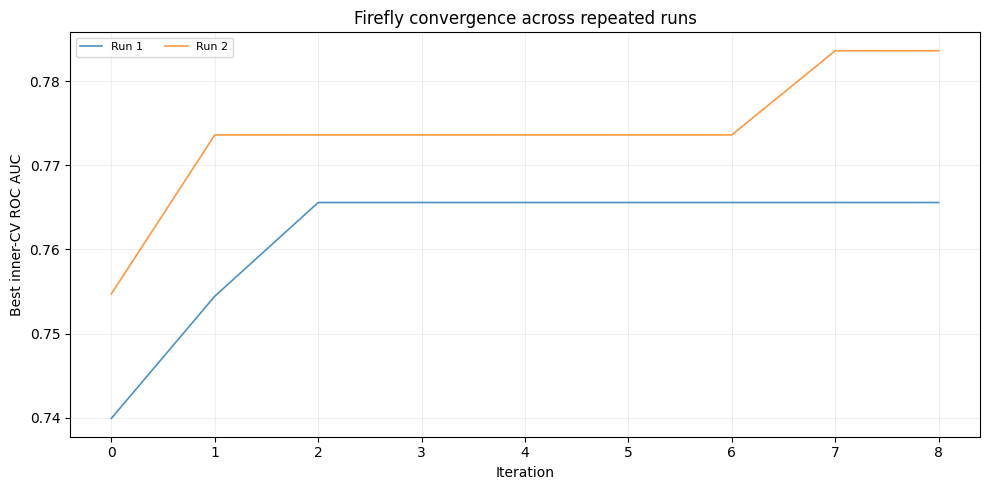

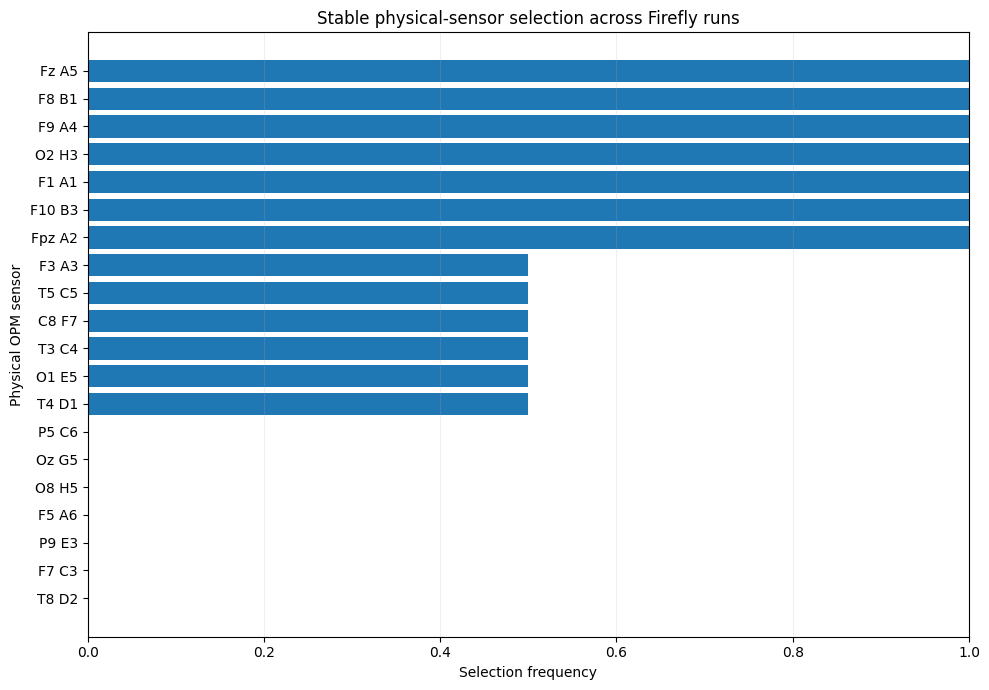

Saved: /kaggle/working/flux_firefly/figures/firefly_convergence.png
Saved: /kaggle/working/flux_firefly/figures/firefly_sensor_selection_stability.png


In [16]:
fig, ax = plt.subplots(
    figsize=(10, 5)
)

for run_index, one_run in convergence_df.groupby(
    "run"
):
    ax.plot(
        one_run[
            "iteration"
        ],
        one_run[
            "best_auc"
        ],
        linewidth=1.2,
        alpha=0.8,
        label=f"Run {run_index}",
    )

ax.set(
    title=(
        "Firefly convergence "
        "across repeated runs"
    ),
    xlabel="Iteration",
    ylabel=(
        "Best inner-CV ROC AUC"
    ),
)

ax.grid(
    alpha=0.2
)

if FIREFLY_RUNS <= 10:
    ax.legend(
        fontsize=8,
        ncol=2,
    )

fig.tight_layout()

convergence_figure = (
    FIGURE_ROOT
    / "firefly_convergence.png"
)

fig.savefig(
    convergence_figure,
    dpi=180,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

top_plot_df = (
    consensus_ranking_df.head(
        min(
            20,
            len(
                consensus_ranking_df
            ),
        )
    )
    .sort_values(
        "selection_frequency"
    )
)

fig, ax = plt.subplots(
    figsize=(10, 7)
)

ax.barh(
    top_plot_df[
        "physical_sensor"
    ],
    top_plot_df[
        "selection_frequency"
    ],
)

ax.set(
    title=(
        "Stable physical-sensor "
        "selection across Firefly runs"
    ),
    xlabel=(
        "Selection frequency"
    ),
    ylabel=(
        "Physical OPM sensor"
    ),
    xlim=(0, 1),
)

ax.grid(
    axis="x",
    alpha=0.2,
)

fig.tight_layout()

stability_figure = (
    FIGURE_ROOT
    / "firefly_sensor_selection_stability.png"
)

fig.savefig(
    stability_figure,
    dpi=180,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

print(
    "Saved:",
    convergence_figure,
)
print(
    "Saved:",
    stability_figure,
)

## Consensus Comparison

In [17]:
comparison_cv = (
    RepeatedStratifiedKFold(
        n_splits=min(
            CONSENSUS_CV_SPLITS,
            int(
                np.min(
                    np.bincount(y)
                )
            ),
        ),
        n_repeats=(
            CONSENSUS_CV_REPEATS
        ),
        random_state=(
            RANDOM_STATE
        ),
    )
)

comparison_splits = list(
    comparison_cv.split(
        X_features,
        y,
    )
)

consensus_columns = (
    subset_columns(
        consensus_sensor_subset,
        sensor_feature_columns,
    )
)

all_columns = subset_columns(
    tuple(
        retained_sensor_names
    ),
    sensor_feature_columns,
)

consensus_scores = cross_val_score(
    make_classifier(),
    X_features[
        :,
        consensus_columns,
    ],
    y,
    cv=comparison_splits,
    scoring="roc_auc",
    n_jobs=OUTER_N_JOBS,
)

all_sensor_scores = cross_val_score(
    make_classifier(),
    X_features[
        :,
        all_columns,
    ],
    y,
    cv=comparison_splits,
    scoring="roc_auc",
    n_jobs=OUTER_N_JOBS,
)

rng = np.random.default_rng(
    RANDOM_STATE + 9000
)

random_subset_means = []

for _ in range(
    RANDOM_BASELINE_REPEATS
):
    random_subset = tuple(
        sorted(
            rng.choice(
                retained_sensor_names,
                size=(
                    TARGET_SENSOR_COUNT
                ),
                replace=False,
            ).tolist()
        )
    )

    random_columns = (
        subset_columns(
            random_subset,
            sensor_feature_columns,
        )
    )

    random_scores = cross_val_score(
        make_classifier(),
        X_features[
            :,
            random_columns,
        ],
        y,
        cv=comparison_splits,
        scoring="roc_auc",
        n_jobs=OUTER_N_JOBS,
    )

    random_subset_means.append(
        float(
            np.mean(
                random_scores
            )
        )
    )

comparison_df = pd.DataFrame(
    [
        {
            "sensor_set": (
                "Firefly consensus"
            ),
            "n_physical_sensors": (
                len(
                    consensus_sensor_subset
                )
            ),
            "mean_auc": float(
                np.mean(
                    consensus_scores
                )
            ),
            "std_auc": float(
                np.std(
                    consensus_scores
                )
            ),
            "interpretation": (
                "exploratory_full_data_selection"
            ),
        },
        {
            "sensor_set": (
                "All physical sensors"
            ),
            "n_physical_sensors": (
                len(
                    retained_sensor_names
                )
            ),
            "mean_auc": float(
                np.mean(
                    all_sensor_scores
                )
            ),
            "std_auc": float(
                np.std(
                    all_sensor_scores
                )
            ),
            "interpretation": (
                "baseline"
            ),
        },
        {
            "sensor_set": (
                "Random subsets"
            ),
            "n_physical_sensors": (
                TARGET_SENSOR_COUNT
            ),
            "mean_auc": float(
                np.mean(
                    random_subset_means
                )
            ),
            "std_auc": float(
                np.std(
                    random_subset_means
                )
            ),
            "interpretation": (
                "random_subset_baseline"
            ),
        },
    ]
)

display(
    comparison_df
)

comparison_df.to_csv(
    REPORT_ROOT
    / "exploratory_firefly_comparison.csv",
    index=False,
)

,sensor_set,n_physical_sensors,mean_auc,std_auc,interpretation
0,Firefly consensus,10,0.719375,0.139718,exploratory_full_data_selection
1,All physical sensors,62,0.624375,0.131731,baseline
2,Random subsets,10,0.598604,0.043405,random_subset_baseline


## Cross-validation

In [18]:
nested_fold_rows = []
nested_prediction_rows = []
nested_selection_counter = Counter()

if RUN_NESTED_CV:
    effective_outer_splits = min(
        OUTER_SPLITS,
        int(
            np.min(
                np.bincount(y)
            )
        ),
    )

    outer_cv = StratifiedKFold(
        n_splits=(
            effective_outer_splits
        ),
        shuffle=True,
        random_state=(
            RANDOM_STATE
        ),
    )

    for fold_index, (
        train_indices,
        test_indices,
    ) in enumerate(
        outer_cv.split(
            X_features,
            y,
        ),
        start=1,
    ):
        print(
            f"Nested outer fold "
            f"{fold_index}/"
            f"{effective_outer_splits}"
        )

        X_train = X_features[
            train_indices
        ]
        y_train = y[
            train_indices
        ]
        X_test = X_features[
            test_indices
        ]
        y_test = y[
            test_indices
        ]

        fold_heuristic, _ = (
            compute_sensor_heuristics(
                X_train,
                y_train,
                retained_sensor_names,
                sensor_feature_columns,
                INNER_SPLITS,
                RANDOM_STATE
                + 1000
                + fold_index,
            )
        )

        fold_redundancy = (
            compute_sensor_redundancy(
                X_train,
                retained_sensor_names,
                sensor_feature_columns,
            )
        )

        fold_result = run_firefly(
            X=X_train,
            y_values=y_train,
            sensor_names=(
                retained_sensor_names
            ),
            sensor_columns=(
                sensor_feature_columns
            ),
            heuristic=(
                fold_heuristic
            ),
            redundancy_matrix=(
                fold_redundancy
            ),
            subset_size=(
                TARGET_SENSOR_COUNT
            ),
            n_fireflies=(
                N_FIREFLIES
            ),
            iterations=(
                FIREFLY_ITERATIONS
            ),
            inner_splits=(
                INNER_SPLITS
            ),
            seed=(
                RANDOM_STATE
                + 2000
                + fold_index
            ),
        )

        nested_selection_counter.update(
            fold_result.best_subset
        )

        fold_columns = subset_columns(
            fold_result.best_subset,
            sensor_feature_columns,
        )

        fold_model = make_classifier()

        fold_model.fit(
            X_train[
                :,
                fold_columns,
            ],
            y_train,
        )

        decision_scores = (
            fold_model.decision_function(
                X_test[
                    :,
                    fold_columns,
                ]
            )
        )

        predictions = (
            decision_scores >= 0.0
        ).astype(int)

        fold_auc = roc_auc_score(
            y_test,
            decision_scores,
        )

        nested_fold_rows.append(
            {
                "outer_fold": (
                    fold_index
                ),
                "test_auc": float(
                    fold_auc
                ),
                "test_accuracy": float(
                    accuracy_score(
                        y_test,
                        predictions,
                    )
                ),
                "test_balanced_accuracy": float(
                    balanced_accuracy_score(
                        y_test,
                        predictions,
                    )
                ),
                "inner_best_auc": float(
                    fold_result.best_auc
                ),
                "selected_sensors": "|".join(
                    fold_result.best_subset
                ),
                "n_train": len(
                    train_indices
                ),
                "n_test": len(
                    test_indices
                ),
            }
        )

        for local_index, global_index in enumerate(
            test_indices
        ):
            nested_prediction_rows.append(
                {
                    "outer_fold": (
                        fold_index
                    ),
                    "global_trial_index": int(
                        global_index
                    ),
                    "true_label": int(
                        y_test[
                            local_index
                        ]
                    ),
                    "decision_score": float(
                        decision_scores[
                            local_index
                        ]
                    ),
                    "predicted_label": int(
                        predictions[
                            local_index
                        ]
                    ),
                }
            )

        print(
            "  held-out AUC:",
            f"{fold_auc:.4f}",
        )
        print(
            "  sensors:",
            fold_result.best_subset,
        )

    nested_fold_df = pd.DataFrame(
        nested_fold_rows
    )

    nested_prediction_df = (
        pd.DataFrame(
            nested_prediction_rows
        )
        .sort_values(
            "global_trial_index"
        )
    )

    nested_summary_df = pd.DataFrame(
        [
            {
                "outer_folds": (
                    effective_outer_splits
                ),
                "mean_fold_auc": float(
                    nested_fold_df[
                        "test_auc"
                    ].mean()
                ),
                "std_fold_auc": float(
                    nested_fold_df[
                        "test_auc"
                    ].std(
                        ddof=1
                    )
                    if len(
                        nested_fold_df
                    ) > 1
                    else 0.0
                ),
                "pooled_oof_auc": float(
                    roc_auc_score(
                        nested_prediction_df[
                            "true_label"
                        ],
                        nested_prediction_df[
                            "decision_score"
                        ],
                    )
                ),
                "pooled_oof_accuracy": float(
                    accuracy_score(
                        nested_prediction_df[
                            "true_label"
                        ],
                        nested_prediction_df[
                            "predicted_label"
                        ],
                    )
                ),
                "pooled_oof_balanced_accuracy": float(
                    balanced_accuracy_score(
                        nested_prediction_df[
                            "true_label"
                        ],
                        nested_prediction_df[
                            "predicted_label"
                        ],
                    )
                ),
                "target_sensor_count": (
                    TARGET_SENSOR_COUNT
                ),
            }
        ]
    )

    display(
        nested_fold_df
    )
    display(
        nested_summary_df
    )

    nested_fold_df.to_csv(
        REPORT_ROOT
        / "nested_cv_folds.csv",
        index=False,
    )

    nested_prediction_df.to_csv(
        REPORT_ROOT
        / "nested_cv_oof_predictions.csv",
        index=False,
    )

    nested_summary_df.to_csv(
        REPORT_ROOT
        / "nested_cv_summary.csv",
        index=False,
    )

    nested_stability_df = (
        pd.DataFrame(
            [
                {
                    "physical_sensor": (
                        sensor_name
                    ),
                    "outer_fold_selection_count": int(
                        nested_selection_counter[
                            sensor_name
                        ]
                    ),
                    "outer_fold_selection_frequency": float(
                        nested_selection_counter[
                            sensor_name
                        ]
                        / effective_outer_splits
                    ),
                }
                for sensor_name
                in retained_sensor_names
            ]
        )
        .sort_values(
            "outer_fold_selection_count",
            ascending=False,
        )
    )

    nested_stability_df.to_csv(
        REPORT_ROOT
        / "nested_cv_sensor_stability.csv",
        index=False,
    )

else:
    nested_fold_df = pd.DataFrame()
    nested_prediction_df = pd.DataFrame()
    nested_summary_df = pd.DataFrame()
    nested_stability_df = pd.DataFrame()

    print(
        "Nested cross-validation "
        "is disabled."
    )

Nested outer fold 1/3
  held-out AUC: 0.4945
  sensors: ('C5 C1', 'C8 F7', 'Cz E2', 'F6 B8', 'F8 B1', 'Fpz A2', 'Iz H4', 'Oz G5', 'P11 E6', 'P2 F3')
Nested outer fold 2/3
  held-out AUC: 0.5879
  sensors: ('F12 D8', 'F2 B7', 'F9 A4', 'Fz A5', 'O2 H3', 'P10 F5', 'P12 F4', 'P4 D3', 'T1 C7', 'T11 G7')
Nested outer fold 3/3
  held-out AUC: 0.4793
  sensors: ('C8 F7', 'Cz E2', 'F10 B3', 'F11 A8', 'F7 C3', 'FCz F6', 'O1 E5', 'O8 H5', 'P2 F3', 'T9 G1')


,outer_fold,test_auc,test_accuracy,test_balanced_accuracy,inner_best_auc,selected_sensors,n_train,n_test
0,1,0.494505,0.555556,0.554945,0.784465,C5 C1|C8 F7|Cz E2|F6 B8|F8 B1|Fpz A2|Iz H4|Oz ...,53,27
1,2,0.587912,0.592593,0.593407,0.595679,F12 D8|F2 B7|F9 A4|Fz A5|O2 H3|P10 F5|P12 F4|P...,53,27
2,3,0.479290,0.576923,0.576923,0.773663,C8 F7|Cz E2|F10 B3|F11 A8|F7 C3|FCz F6|O1 E5|O...,54,26


,outer_folds,mean_fold_auc,std_fold_auc,pooled_oof_auc,pooled_oof_accuracy,pooled_oof_balanced_accuracy,target_sensor_count
0,3,0.520569,0.058815,0.53375,0.575,0.575,10


## CV performance plot

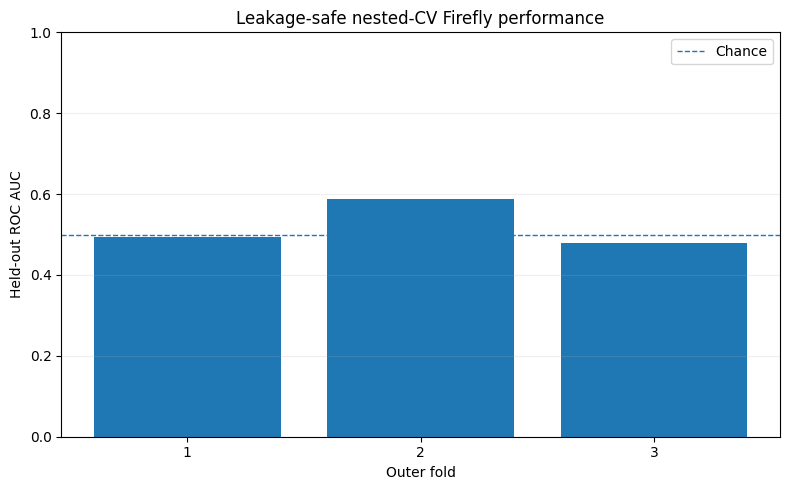

Saved: /kaggle/working/flux_firefly/figures/nested_cv_fold_auc.png


In [19]:
if not nested_fold_df.empty:
    fig, ax = plt.subplots(
        figsize=(8, 5)
    )

    ax.bar(
        nested_fold_df[
            "outer_fold"
        ].astype(str),
        nested_fold_df[
            "test_auc"
        ],
    )

    ax.axhline(
        0.5,
        linestyle="--",
        linewidth=1.0,
        label="Chance",
    )

    ax.set(
        title=(
            "Leakage-safe nested-CV "
            "Firefly performance"
        ),
        xlabel="Outer fold",
        ylabel=(
            "Held-out ROC AUC"
        ),
        ylim=(0, 1),
    )

    ax.grid(
        axis="y",
        alpha=0.2,
    )
    ax.legend()

    fig.tight_layout()

    nested_figure = (
        FIGURE_ROOT
        / "nested_cv_fold_auc.png"
    )

    fig.savefig(
        nested_figure,
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)

    print(
        "Saved:",
        nested_figure,
    )

## Sensor-count curve

In [20]:
sensor_count_rows = []

if RUN_SENSOR_COUNT_CURVE:
    valid_counts = [
        count
        for count in SENSOR_COUNTS_TO_TEST
        if (
            1
            <= count
            <= len(
                retained_sensor_names
            )
        )
    ]

    for sensor_count in valid_counts:
        print(
            "Sensor count:",
            sensor_count,
        )

        result = run_firefly(
            X=X_features,
            y_values=y,
            sensor_names=(
                retained_sensor_names
            ),
            sensor_columns=(
                sensor_feature_columns
            ),
            heuristic=(
                full_heuristic
            ),
            redundancy_matrix=(
                full_redundancy
            ),
            subset_size=(
                sensor_count
            ),
            n_fireflies=(
                COUNT_CURVE_FIREFLIES
            ),
            iterations=(
                COUNT_CURVE_ITERATIONS
            ),
            inner_splits=(
                INNER_SPLITS
            ),
            seed=(
                RANDOM_STATE
                + 5000
                + sensor_count
            ),
        )

        sensor_count_rows.append(
            {
                "n_physical_sensors": (
                    sensor_count
                ),
                "best_inner_cv_auc": (
                    result.best_auc
                ),
                "best_fitness": (
                    result.best_fitness
                ),
                "mean_redundancy": (
                    result.best_redundancy
                ),
                "selected_sensors": "|".join(
                    result.best_subset
                ),
            }
        )

    sensor_count_df = pd.DataFrame(
        sensor_count_rows
    )

    display(
        sensor_count_df
    )

    sensor_count_df.to_csv(
        REPORT_ROOT
        / "firefly_sensor_count_curve.csv",
        index=False,
    )

    fig, ax = plt.subplots(
        figsize=(9, 5)
    )

    ax.plot(
        sensor_count_df[
            "n_physical_sensors"
        ],
        sensor_count_df[
            "best_inner_cv_auc"
        ],
        marker="o",
    )

    ax.axhline(
        0.5,
        linestyle="--",
        linewidth=1.0,
    )

    ax.set(
        title=(
            "Firefly performance versus "
            "physical-sensor count"
        ),
        xlabel=(
            "Number of physical sensors"
        ),
        ylabel=(
            "Best inner-CV ROC AUC"
        ),
    )

    ax.grid(
        alpha=0.2
    )

    fig.tight_layout()

    count_figure = (
        FIGURE_ROOT
        / "firefly_sensor_count_curve.png"
    )

    fig.savefig(
        count_figure,
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)

else:
    sensor_count_df = pd.DataFrame()

    print(
        "Sensor-count curve disabled. "
        "Set RUN_SENSOR_COUNT_CURVE=True."
    )

Sensor-count curve disabled. Set RUN_SENSOR_COUNT_CURVE=True.


## Exploratory time-resolved decoding

Exploratory peak: AUC=0.7250 time=0.861 s


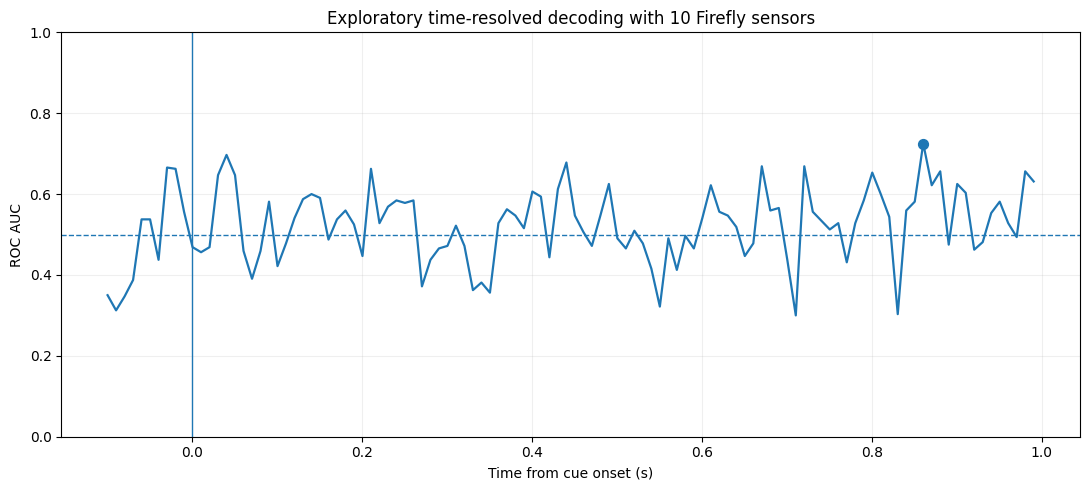

In [21]:
time_resolved_df = pd.DataFrame()

if RUN_TIME_RESOLVED_DECODING:
    consensus_channels = []

    for sensor_name in consensus_sensor_subset:
        consensus_channels.extend(
            [
                channel
                for channel
                in sensor_to_channels[
                    sensor_name
                ]
                if (
                    channel
                    in signal_channel_names
                )
            ]
        )

    channel_indices = [
        signal_channel_names.index(
            channel
        )
        for channel
        in consensus_channels
    ]

    time_mask = (
        (
            signal_times
            >= TIME_DECODING_TMIN_S
        )
        & (
            signal_times
            <= TIME_DECODING_TMAX_S
        )
    )

    decoding_times = (
        signal_times[
            time_mask
        ]
    )

    X_time = X_signal[
        :,
        channel_indices,
        :,
    ][
        :,
        :,
        time_mask,
    ]

    effective_splits = min(
        TIME_DECODING_CV_SPLITS,
        int(
            np.min(
                np.bincount(y)
            )
        ),
    )

    cv = StratifiedKFold(
        n_splits=(
            effective_splits
        ),
        shuffle=True,
        random_state=(
            RANDOM_STATE
        ),
    )

    cv_splits = list(
        cv.split(
            X_time,
            y,
        )
    )

    time_auc = []

    for time_index in range(
        X_time.shape[2]
    ):
        scores = cross_val_score(
            make_classifier(),
            X_time[
                :,
                :,
                time_index,
            ],
            y,
            cv=cv_splits,
            scoring="roc_auc",
            n_jobs=(
                INNER_N_JOBS
            ),
        )

        time_auc.append(
            float(
                np.mean(
                    scores
                )
            )
        )

    time_resolved_df = pd.DataFrame(
        {
            "time_s": decoding_times,
            "mean_auc": time_auc,
        }
    )

    peak_row = time_resolved_df.iloc[
        int(
            np.argmax(
                time_resolved_df[
                    "mean_auc"
                ].to_numpy()
            )
        )
    ]

    print(
        "Exploratory peak:",
        f"AUC={peak_row['mean_auc']:.4f}",
        f"time={peak_row['time_s']:.3f} s",
    )

    time_resolved_df.to_csv(
        REPORT_ROOT
        / "consensus_sensor_time_resolved_auc.csv",
        index=False,
    )

    fig, ax = plt.subplots(
        figsize=(11, 5)
    )

    ax.plot(
        time_resolved_df[
            "time_s"
        ],
        time_resolved_df[
            "mean_auc"
        ],
        linewidth=1.6,
    )

    ax.axhline(
        0.5,
        linestyle="--",
        linewidth=1.0,
    )

    ax.axvline(
        0.0,
        linewidth=1.0,
    )

    ax.scatter(
        [
            peak_row[
                "time_s"
            ]
        ],
        [
            peak_row[
                "mean_auc"
            ]
        ],
        s=50,
    )

    ax.set(
        title=(
            f"Exploratory time-resolved "
            f"decoding with "
            f"{TARGET_SENSOR_COUNT} "
            f"Firefly sensors"
        ),
        xlabel=(
            "Time from cue onset (s)"
        ),
        ylabel="ROC AUC",
        ylim=(0, 1),
    )

    ax.grid(
        alpha=0.2
    )

    fig.tight_layout()

    time_figure = (
        FIGURE_ROOT
        / "consensus_sensor_time_resolved_auc.png"
    )

    fig.savefig(
        time_figure,
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)

else:
    print(
        "Time-resolved decoding "
        "is disabled."
    )

## Time-resolved energy for leading sensors plot

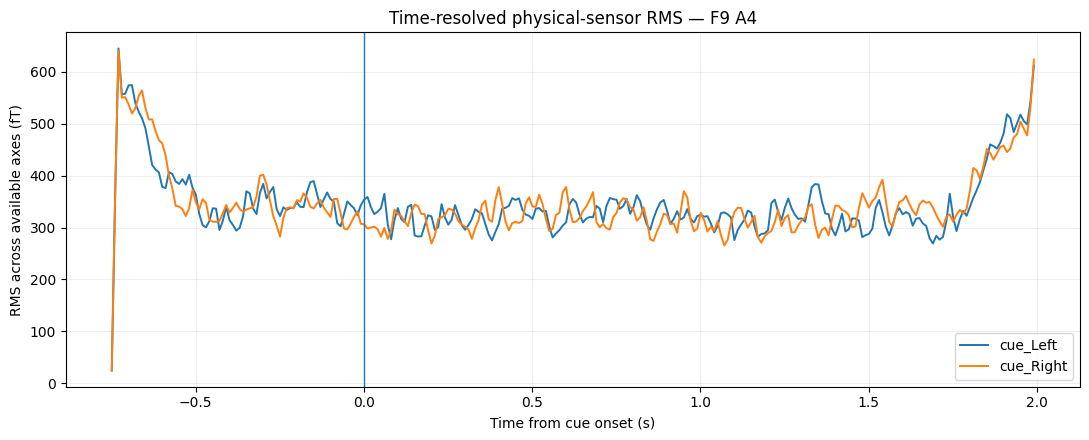

Saved: /kaggle/working/flux_firefly/figures/energy_F9_A4.png


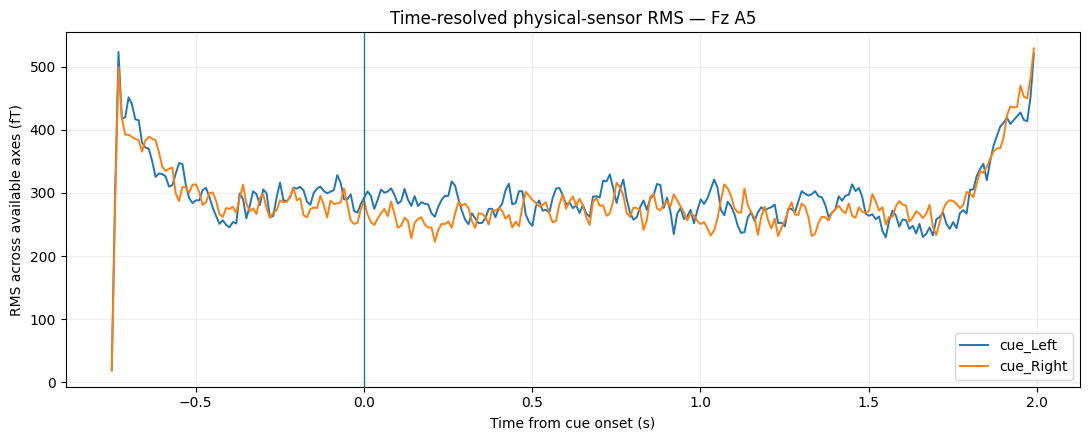

Saved: /kaggle/working/flux_firefly/figures/energy_Fz_A5.png


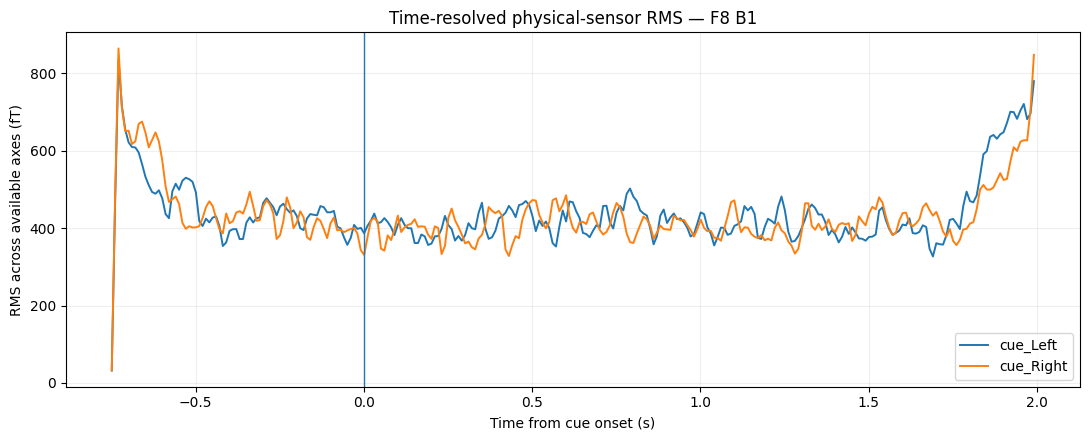

Saved: /kaggle/working/flux_firefly/figures/energy_F8_B1.png


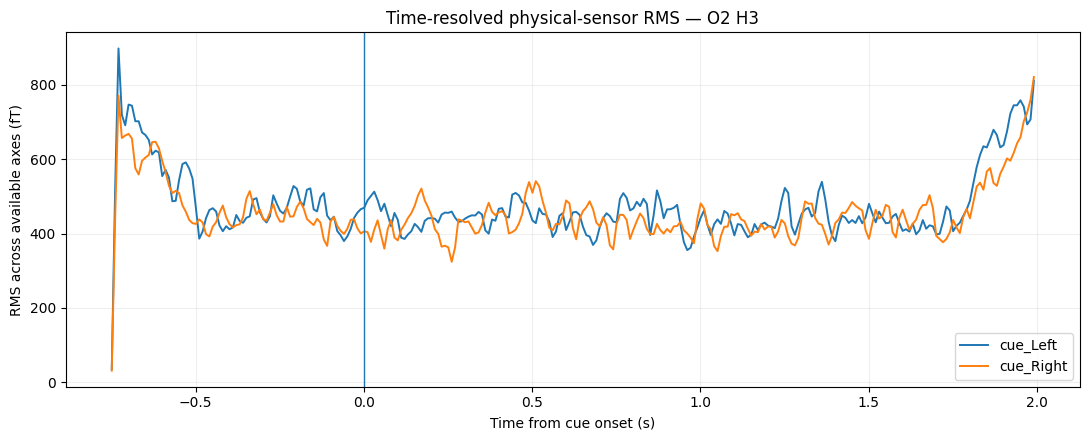

Saved: /kaggle/working/flux_firefly/figures/energy_O2_H3.png


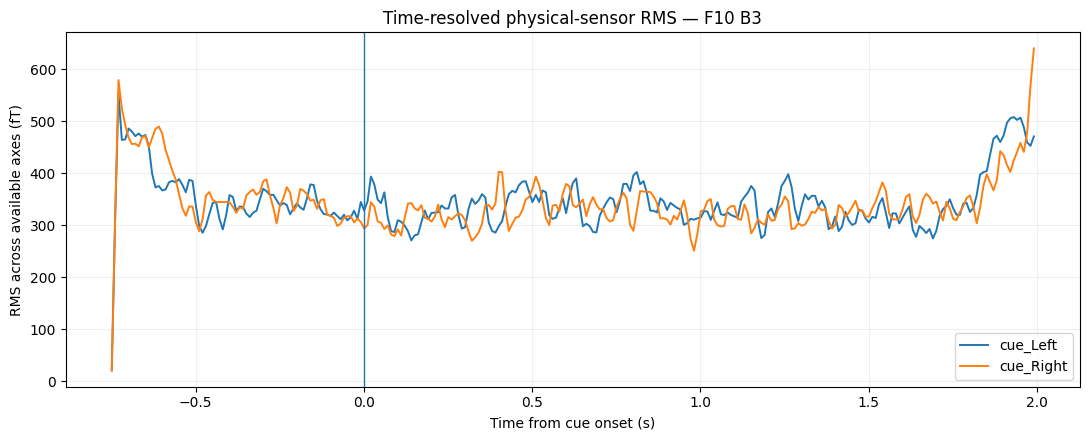

Saved: /kaggle/working/flux_firefly/figures/energy_F10_B3.png


In [22]:
leading_sensors = list(
    consensus_sensor_subset[
        :TOP_SENSORS_FOR_ENERGY_PLOTS
    ]
)

for sensor_name in leading_sensors:
    indices = [
        signal_channel_names.index(
            channel
        )
        for channel
        in sensor_to_channels[
            sensor_name
        ]
        if (
            channel
            in signal_channel_names
        )
    ]

    sensor_signal = X_signal[
        :,
        indices,
        :,
    ]

    sensor_energy = np.sqrt(
        np.mean(
            sensor_signal**2,
            axis=1,
        )
    ) * 1e15

    left_mean = np.mean(
        sensor_energy[
            y == 0
        ],
        axis=0,
    )

    right_mean = np.mean(
        sensor_energy[
            y == 1
        ],
        axis=0,
    )

    fig, ax = plt.subplots(
        figsize=(11, 4.5)
    )

    ax.plot(
        signal_times,
        left_mean,
        linewidth=1.4,
        label="cue_Left",
    )

    ax.plot(
        signal_times,
        right_mean,
        linewidth=1.4,
        label="cue_Right",
    )

    ax.axvline(
        0.0,
        linewidth=1.0,
    )

    ax.set(
        title=(
            "Time-resolved "
            f"physical-sensor RMS — "
            f"{sensor_name}"
        ),
        xlabel=(
            "Time from cue onset (s)"
        ),
        ylabel=(
            "RMS across available axes "
            "(fT)"
        ),
    )

    ax.grid(
        alpha=0.2
    )
    ax.legend()

    fig.tight_layout()

    safe_name = re.sub(
        r"[^A-Za-z0-9]+",
        "_",
        sensor_name,
    ).strip("_")

    output = (
        FIGURE_ROOT
        / f"energy_{safe_name}.png"
    )

    fig.savefig(
        output,
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)

    print(
        "Saved:",
        output,
    )

## Save 1

In [23]:
consensus_columns = subset_columns(
    consensus_sensor_subset,
    sensor_feature_columns,
)

final_model = make_classifier()

final_model.fit(
    X_features[
        :,
        consensus_columns,
    ],
    y,
)

model_path = (
    MODEL_ROOT
    / (
        f"sub-{SUBJECT}_ses-{SESSION}_"
        f"task-{TASK}_run-{RUN}_"
        f"desc-firefly-"
        f"{TARGET_SENSOR_COUNT}sensor-"
        f"linear-svm.joblib"
    )
)

joblib.dump(
    {
        "model": final_model,
        "physical_sensors": list(
            consensus_sensor_subset
        ),
        "sensor_to_channels": {
            sensor_name: (
                sensor_to_channels[
                    sensor_name
                ]
            )
            for sensor_name
            in consensus_sensor_subset
        },
        "feature_columns": (
            consensus_columns
        ),
        "feature_names": [
            feature_names[index]
            for index
            in consensus_columns
        ],
        "filter_hz": [
            FILTER_L_FREQ_HZ,
            FILTER_H_FREQ_HZ,
        ],
        "resample_hz": (
            RESAMPLE_HZ
        ),
        "feature_window_s": [
            FEATURE_TMIN_S,
            FEATURE_TMAX_S,
        ],
        "n_time_windows": (
            N_TIME_WINDOWS
        ),
        "class_mapping": {
            0: "cue_Left",
            1: "cue_Right",
        },
        "warning": (
            "Model fitted after full-data "
            "exploratory selection. "
            "Use nested-CV metrics for "
            "generalisation reporting."
        ),
    },
    model_path,
)

print(
    "Saved:",
    model_path,
)

Saved: /kaggle/working/flux_firefly/models/sub-01_ses-01_task-SpAtt_run-01_desc-firefly-10sensor-linear-svm.joblib


## Save 2

In [25]:
nested_records = (
    []
    if nested_summary_df.empty
    else nested_summary_df.to_dict(
        orient="records"
    )
)

summary = {
    "input_epochs_file": str(
        EPOCHS_FILE
    ),
    "quick_mode": bool(
        QUICK_MODE
    ),
    "class_counts": {
        "cue_Left": int(
            np.sum(y == 0)
        ),
        "cue_Right": int(
            np.sum(y == 1)
        ),
    },
    "physical_sensors": {
        "discovered": int(
            len(
                sensor_inventory_df
            )
        ),
        "retained": int(
            len(
                retained_sensor_names
            )
        ),
        "require_complete_xyz": bool(
            REQUIRE_COMPLETE_XYZ
        ),
    },
    "feature_matrix_shape": list(
        X_features.shape
    ),
    "firefly": {
        "target_sensor_count": int(
            TARGET_SENSOR_COUNT
        ),
        "n_fireflies": int(
            N_FIREFLIES
        ),
        "iterations": int(
            FIREFLY_ITERATIONS
        ),
        "runs": int(
            FIREFLY_RUNS
        ),
        "beta0": float(
            FIREFLY_BETA0
        ),
        "gamma": float(
            FIREFLY_GAMMA
        ),
        "alpha_initial": float(
            FIREFLY_ALPHA_INITIAL
        ),
        "alpha_decay": float(
            FIREFLY_ALPHA_DECAY
        ),
        "redundancy_weight": float(
            REDUNDANCY_WEIGHT
        ),
        "consensus_sensors": list(
            consensus_sensor_subset
        ),
        "mean_run_best_auc": float(
            run_df[
                "best_auc"
            ].mean()
        ),
        "std_run_best_auc": float(
            run_df[
                "best_auc"
            ].std(
                ddof=1
            )
            if len(
                run_df
            ) > 1
            else 0.0
        ),
    },
    "exploratory_comparison": (
        comparison_df.to_dict(
            orient="records"
        )
    ),
    "nested_cv": (
        nested_records
    ),
    "sensor_count_curve_run": bool(
        RUN_SENSOR_COUNT_CURVE
    ),
    "time_resolved_decoding_run": bool(
        RUN_TIME_RESOLVED_DECODING
    ),
    "model_file": str(
        model_path
    ),
    "figures": sorted(
        str(
            path.relative_to(
                WORK_ROOT
            )
        )
        for path in FIGURE_ROOT.glob("*")
        if path.is_file()
    ),
    "reports": sorted(
        str(
            path.relative_to(
                WORK_ROOT
            )
        )
        for path in REPORT_ROOT.glob("*")
        if path.is_file()
    ),
}

summary_path = (
    REPORT_ROOT
    / "firefly_sensor_selection_summary.json"
)

summary_path.write_text(
    json.dumps(
        summary,
        indent=2,
        allow_nan=False,
    ),
    encoding="utf-8",
)

print(
    "Saved:",
    summary_path,
)

Saved: /kaggle/working/flux_firefly/reports/firefly_sensor_selection_summary.json


## Zip

In [26]:
figures_zip = shutil.make_archive(
    "/kaggle/working/FLUX_Firefly_figures",
    "zip",
    root_dir=FIGURE_ROOT,
)

reports_zip = shutil.make_archive(
    "/kaggle/working/FLUX_Firefly_reports",
    "zip",
    root_dir=REPORT_ROOT,
)

models_zip = shutil.make_archive(
    "/kaggle/working/FLUX_Firefly_models",
    "zip",
    root_dir=MODEL_ROOT,
)

print(
    "Figures ZIP:",
    figures_zip,
)
print(
    "Reports ZIP:",
    reports_zip,
)
print(
    "Models ZIP:",
    models_zip,
)

Figures ZIP: /kaggle/working/FLUX_Firefly_figures.zip
Reports ZIP: /kaggle/working/FLUX_Firefly_reports.zip
Models ZIP: /kaggle/working/FLUX_Firefly_models.zip
